In [1]:
# Day 4 — Agentic AI & Multi-Agent Network Operations

In [2]:
# How can we build an AI-powered Network Operations Center (NOC) where AI agents can investigate network/infrastructure incidents autonomously, collaborate with specialist agents, recommend the right remediation, but still remain inside strict security and human-approval boundaries?

In [3]:
# Imagine a company like Walmart has a network/infrastructure problem:

# “Something is wrong. Maybe an application is slow, a network component is behaving incorrectly, or an infrastructure service is unhealthy.”

# Normally, a network engineer would manually do things like:
#     Incident comes → check monitoring → inspect configuration → check recent changes → look at documentation/issues → form possible root causes → validate them → recommend a fix.

# Can AI agents perform this investigation intelligently and systematically instead of an engineer manually jumping between ten different systems?

# But there is an important condition:
#     The AI should investigate and reason autonomously, but it should NOT blindly make production changes.

# That is really the central theme of the notebook.

In [4]:
# You can think of the notebook as building this system:

# Network Incident
# ↓
# AI Coordinator understands the incident
# ↓
# Collect evidence
# ↓
# Check monitoring
# ↓
# Check configuration
# ↓
# Check changes / documentation / known issues
# ↓
# Generate possible root causes
# ↓
# Validate those root causes
# ↓
# Different specialist AI agents collaborate
# ↓
# Recommend remediation
# ↓
# Security/Policy checks whether it is allowed
# ↓
# Human approval if required
# ↓
# Controlled execution
# ↓
# Validate whether the problem was fixed
# ↓
# Rollback or escalate if necessary

In [5]:
# Suppose the complaint is:
#   “Our checkout application has suddenly become slow.”

# Instead of asking one ChatGPT-like assistant:
# “Why is checkout slow?”

# an agentic system works differently.
# It may decide:
# Step 1: “I need monitoring data.”
# It calls the monitoring tool.
# Suppose monitoring data isn't available.
# The agent should not invent it.

# It records:
# Monitoring = UNAVAILABLE
# and continues investigating using other authorized evidence.

# Then it may decide:
# Step 2: “Let me inspect configuration.”

# Step 3: “Let me check recent known issues.”

# Step 4: “Let me check documentation.”

# Step 5: “Based on the evidence, these are the likely causes.”

# Then another agent may challenge that conclusion.

# Finally the system may recommend:
#   “The evidence suggests configuration X may be causing the issue. I recommend restoring configuration Y.”

# But that recommendation does not mean the AI changes the router/server.
# That is one of the most important ideas in this notebook:
# Recommendation ≠ Execution.

In [6]:
# Why Multi-Agent AI comes into the picture

# A single AI agent could potentially call every tool.

# But in a large enterprise NOC, different systems have different responsibilities and permissions.

# So the notebook introduces specialist agents such as agents responsible for things like:
#     Telemetry → Configuration → Topology → Knowledge → Root Cause Analysis → Security/Policy → Remediation → Validation → Coordination.

# The important idea is not simply giving ten agents fancy names.

# The notebook explicitly argues that separate agents are useful when they have genuinely different:
#     data access, tools, permissions, context, responsibilities, evaluation criteria, or failure boundaries.

# For example:
# Telemetry Agent
#     “I can inspect monitoring information, but I cannot modify infrastructure.”

# Configuration Agent
#     “I can inspect configuration information.”

# RCA Agent
#     “Give me the collected evidence and I will determine the most plausible root causes.”

# Security Policy Agent
#     “Even if the RCA agent suggests something, I determine whether that proposed action is permitted.”

# Remediation Agent
#     “I create the recommended fix, validation steps and rollback plan.”

# So one agent does not get unlimited power.

In [7]:
# Another major problem being solved: AI memory

# During a long network incident, an AI agent needs to remember things like:
#     “DNS was already checked.”
#     “Monitoring wasn't available.”
#     “Configuration evidence came from this source.”
#     “We are currently validating hypothesis #2.”

# But this introduces another risk.

# Imagine yesterday's incident information contaminating today's investigation.

# Therefore the notebook differentiates between:
#     short-term memory, persistent memory, workflow state and incident context.

# Essentially:
#     AI should remember what it needs, but only within the correct incident, environment and time boundary.

In [8]:
    #           NETWORK INCIDENT
    #                  ↓
    #          Coordinator Agent
    #                  ↓
    #        ┌─────────┼─────────┐
    #        ↓         ↓         ↓
    #    Telemetry   Config   Knowledge
    #     Agent      Agent      Agent
    #        └─────────┼─────────┘
    #                  ↓
    #               RCA Agent
    #                  ↓
    #          Possible Root Cause
    #                  ↓
    #         Security/Policy Agent
    #                  ↓
    #           Remediation Agent
    #                  ↓
    #       Validation / Challenge
    #                  ↓
    #            Human Approval
    #                  ↓
    #       Controlled Execution
    #                  ↓
    #     Validate → Rollback/Escalate

## Setup — stable, pinned, and offline-first

Tested together in the shared **`wal_net`** environment on Python 3.12.13 using the unified `requirements.txt`.

```bash
python3.12 -m venv wal_net
source wal_net/bin/activate          # Windows: wal_net\Scripts\activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name wal_net --display-name "Python (wal_net)"
```

Select the **Python (wal_net)** kernel in VS Code. Core LangGraph labs require no API key. The official OpenAI Agents SDK mapping is imported and instantiated locally; a live SDK run is separately guarded by three explicit environment settings.

In [9]:
from __future__ import annotations

import hashlib
import operator
import importlib.metadata as metadata
import json
import math
import os
import platform
import re
import sqlite3
import tempfile
import time
import uuid
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Annotated, Any, Callable, Literal, TypedDict

import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from pydantic import BaseModel, ConfigDict, Field, ValidationError, model_validator
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 120)
RANDOM_STATE = 42

print("Python:", platform.python_version())
print("Platform:", platform.platform())

Python: 3.12.13
Platform: macOS-26.6.2-arm64-arm-64bit


## Graph visualization helper

The essential LangGraph visualization pattern is:

```python
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))
```

`show_langgraph_figure()` applies that same pattern to every compiled graph in this notebook. PNG generation normally uses LangGraph’s Mermaid rendering service and therefore needs internet access. If that service is unavailable, the helper prints the Mermaid definition instead of failing the lesson.

In [10]:
def show_langgraph_figure(compiled_graph, title: str) -> None:
    '''Display a compiled LangGraph as a Mermaid PNG, with a safe text fallback.'''
    print(f"\n{title}")
    try:
        # User-requested visualization pattern:
        display(Image(compiled_graph.get_graph().draw_mermaid_png()))
    except Exception as exc:
        print(f"PNG rendering unavailable ({type(exc).__name__}). Mermaid source follows:")
        print(compiled_graph.get_graph().draw_mermaid())

In [11]:
EXPECTED = {
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "scikit-learn": "1.9.0",
    "pydantic": "2.13.4",
    "networkx": "3.6.1",
    "openai": "3.3.1",
    "openai-agents": "0.22.0",
    "langgraph": "1.2.11",
    "nbformat": "5.11.1",
    "nbclient": "0.11.0",
    "ipykernel": "7.3.0",
}
installed = {name: metadata.version(name) for name in EXPECTED}
version_check = pd.DataFrame(
    [
        {
            "package": name,
            "expected": expected,
            "installed": installed[name],
            "match": installed[name] == expected,
        }
        for name, expected in EXPECTED.items()
    ]
)
display(version_check)
assert tuple(map(int, platform.python_version_tuple()[:2])) >= (3, 12)
assert version_check["match"].all(), "Install the exact Session 4 requirements before continuing."
print("✓ Runtime matches the tested package set")

,package,expected,installed,match
0,numpy,2.5.2,2.5.2,True
1,pandas,3.0.5,3.0.5,True
2,scikit-learn,1.9.0,1.9.0,True
3,pydantic,2.13.4,2.13.4,True
4,networkx,3.6.1,3.6.1,True
5,openai,3.3.1,3.3.1,True
6,openai-agents,0.22.0,0.22.0,True
7,langgraph,1.2.11,1.2.11,True
8,nbformat,5.11.1,5.11.1,True
9,nbclient,0.11.0,0.11.0,True


✓ Runtime matches the tested package set


In [12]:
def locate_artifact(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "outputs" / filename,
        Path.cwd().parent / "outputs" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not find {filename}. Checked: {candidates}")

CORPUS_PATH = locate_artifact("session3_walmart_network_corpus.jsonl")
MANIFEST_PATH = locate_artifact("session3_source_manifest.json")
records = [json.loads(line) for line in CORPUS_PATH.read_text().splitlines() if line.strip()]
manifest = json.loads(MANIFEST_PATH.read_text())

assert hashlib.sha256(CORPUS_PATH.read_bytes()).hexdigest() == manifest["corpus_sha256"]
assert len(records) == manifest["record_count"]
print(manifest["provenance_statement"])
print(f"✓ Loaded {len(records)} verified public records")

All operational facts and examples are sourced from public Walmart Global Tech or Walmart-originated L3AF project materials. No internal Walmart runbook, configuration, incident, topology, monitoring record, credential, or production state is claimed or fabricated.
✓ Loaded 81 verified public records


In [13]:
corpus_df = pd.DataFrame(records)
display(
    corpus_df.groupby("source_type", as_index=False)
    .agg(records=("doc_id", "count"), example=("title", "first"))
    .sort_values("records", ascending=False)
)

search_texts = (corpus_df["title"] + " " + corpus_df["content"]).tolist()
vectorizer = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), sublinear_tf=True)
corpus_matrix = vectorizer.fit_transform(search_texts)

def search_corpus(query: str, top_k: int = 5, source_types: set[str] | None = None) -> list[dict[str, Any]]:
    if not query.strip():
        raise ValueError("query must not be empty")
    scores = cosine_similarity(vectorizer.transform([query]), corpus_matrix).ravel()
    mask = np.ones(len(corpus_df), dtype=bool)
    if source_types:
        mask = corpus_df["source_type"].isin(source_types).to_numpy()
    candidates = np.where(mask)[0]
    ranked = candidates[np.argsort(scores[candidates])[::-1]][:top_k]
    return [
        {
            **corpus_df.iloc[i].to_dict(),
            "score": float(scores[i]),
        }
        for i in ranked
    ]

display(pd.DataFrame(search_corpus("BPFRunning metric loading error", 3))[["doc_id", "score", "title", "source_url"]])

,source_type,records,example
4,historical_issue,37,L3AFD issue #754: Build failure on Cilium eBPF package upgrade
3,configuration_standard,12,configdoc: L3AFD Config Options Documentation
2,configuration_repository,10,l3afd sample configuration: [l3afd]
9,project_readme,9,README: L3AFD: Lightweight eBPF Daemon
6,operational_runbook,5,graceful-restart-guide: Prerequisites
8,production_deployment_guide,3,prod-deploy-guide: Installing l3afd
7,package_repository_guide,2,README: eBPF Package Repository
0,api_specification,1,l3afd REST API operation inventory
1,change_records,1,L3AFD recent public commit history
5,official_walmart_global_tech_article,1,Walmart Global Tech: published network scale and open-source context


,doc_id,score,title,source_url
0,l3afd-issue-698,0.295954,L3AFD issue #698: l3afd_BPFRunning metric reports true incase of ebpf_program loading error,https://github.com/l3af-project/l3afd/issues/698
1,l3afd-issue-523,0.129092,L3AFD issue #523: Add metrics to count ebpf program loading failure errors,https://github.com/l3af-project/l3afd/issues/523
2,l3afd-issue-637,0.080799,L3AFD issue #637: Remove stale metric reporting on eBPF program unload,https://github.com/l3af-project/l3afd/issues/637


# Module 1 — From GenAI Copilot to Agentic AI

## 1.1 LLM vs chatbot vs copilot vs AI agent

| System | Primary behavior | Initiative | Tools/state | Network example |
|---|---|---:|---|---|
| LLM | predicts a response from context | none | not inherent | explain OSPF adjacency states |
| Chatbot | manages a conversation around an LLM | reactive | conversation history | answer a NetOps FAQ |
| Copilot | assists a human in a workflow | suggestive | often retrieval/tools | propose diagnostic commands |
| AI agent | pursues a goal through a controlled loop | bounded initiative | tools, state, stopping rules | gather evidence and produce a validated investigation |

The difference is not personality. An agent has a **goal, an environment, observations, allowed actions, state, feedback, and termination conditions**.

**Trainer distinction:** a model may recommend a tool call; deterministic code still validates identity, arguments, authorization, execution, and result handling.

### Concept-by-concept operational intuition

| Concept | Simple explanation | Network/infrastructure example | Why it matters |
|---|---|---|---|
| Agent goal | The outcome the workflow is trying to reach | Determine the most supported cause of checkout latency | Prevents endless exploration |
| Instructions | Rules describing how the goal may be pursued | Read-only diagnostics; cite evidence; stop before change | Defines behavior but is reinforced by code |
| Reasoning | Interpret observations and identify what remains unknown | DNS succeeds, so investigate path/firewall evidence next | Converts raw signals into a justified next question |
| Planning | Order safe actions under time and step budgets | Check monitoring, configuration and recent changes | Avoids random or repeated tool use |
| Tools | Approved capabilities exposed to the workflow | `query_monitoring()` or `retrieve_configuration()` | Connects language reasoning to authoritative systems |
| Memory | Information deliberately retained beyond one step | Remember that a route lookup was already completed | Reduces repetition, but creates freshness and privacy risk |
| State | Explicit current workflow truth | Status, evidence IDs, step count and approval flag | Makes execution resumable and testable |
| Observation | A returned fact or failure from the environment | “BGP session up at 10:02 UTC” or “monitoring unavailable” | Evidence—not model belief—should drive conclusions |
| Action | A bounded operation selected by the workflow | Invoke a read-only interface-status tool | Must stay inside permission and blast-radius boundaries |
| Feedback loop | Validation changes the next step | Missing time-aligned logs routes the graph back to collection | Lets the workflow adapt without looping forever |
| Workflow pattern | Reusable control-flow shape | Router, tool loop, manager-specialists or approval state machine | Helps choose a design engineers can operate |

In [14]:
system_comparison = pd.DataFrame(
    [
        {"system": "LLM", "goal_loop": False, "tools": False, "state": False, "acts": False},
        {"system": "Chatbot", "goal_loop": False, "tools": "optional", "state": "conversation", "acts": False},
        {"system": "Copilot", "goal_loop": "human-led", "tools": True, "state": "workflow", "acts": "usually proposes"},
        {"system": "Agent", "goal_loop": "bounded autonomous", "tools": True, "state": "explicit", "acts": "within policy"},
    ]
)
display(system_comparison)

,system,goal_loop,tools,state,acts
0,LLM,False,False,False,False
1,Chatbot,False,optional,conversation,False
2,Copilot,human-led,True,workflow,usually proposes
3,Agent,bounded autonomous,True,explicit,within policy


## 1.2 Agent goals and instructions

“Troubleshoot the network” is not an operational goal. A usable agent contract specifies:

- the outcome and success criteria;
- the evidence domain and authoritative sources;
- allowed tools and targets;
- prohibited actions;
- uncertainty and citation requirements;
- time, step, cost, and retry budgets;
- approval and escalation boundaries;
- stopping conditions.

Keep goals outcome-oriented and instructions behavior-oriented. Policy must remain enforceable outside the model.

In [15]:
# defining a contract/rulebook for our troubleshooting AI agent.

class AgentContract(BaseModel):
    model_config = ConfigDict(extra="forbid")

    name: str
    goal: str
    success_criteria: list[str]
    allowed_tools: set[str]
    prohibited_actions: list[str]
    max_steps: int = Field(ge=1, le=20)
    requires_citations: bool = True
    human_gate_before_write: bool = True

# Sample
# success_criteria = [
#     "required evidence categories are attempted",
#     "hypotheses are labeled by support status",
#     "missing live context is explicit",
#     "recommendation contains no unauthorized execution",
# ]


# Now we create an actual agent contract
troubleshooting_contract = AgentContract(
    name="Public L3AF Evidence Investigator",
    goal="Produce a source-attributed investigation of a public L3AF issue without claiming live access.",
    success_criteria=[
        "required evidence categories are attempted",
        "hypotheses are labeled by support status",
        "missing live context is explicit",
        "recommendation contains no unauthorized execution",
    ],
    allowed_tools={
        "collect_incident_evidence",
        "query_monitoring",
        "inspect_configuration",
        "check_changes",
        "retrieve_knowledge",
    },
    prohibited_actions=["execute shell commands", "change infrastructure", "invent live telemetry"],
    max_steps=10,
)
print(troubleshooting_contract.model_dump_json(indent=2))

{
  "name": "Public L3AF Evidence Investigator",
  "goal": "Produce a source-attributed investigation of a public L3AF issue without claiming live access.",
  "success_criteria": [
    "required evidence categories are attempted",
    "hypotheses are labeled by support status",
    "missing live context is explicit",
    "recommendation contains no unauthorized execution"
  ],
  "allowed_tools": [
    "collect_incident_evidence",
    "inspect_configuration",
    "query_monitoring",
    "check_changes",
    "retrieve_knowledge"
  ],
  "prohibited_actions": [
    "execute shell commands",
    "change infrastructure",
    "invent live telemetry"
  ],
  "max_steps": 10,
  "requires_citations": true,
  "human_gate_before_write": true
}


## 1.3 Reasoning and planning; tools; memory and state

An enterprise agent should expose **decision summaries**, not private chain-of-thought. For every step, record:

- observation received;
- evidence gap detected;
- action selected and why it is allowed;
- tool result and source identifiers;
- state transition;
- validation outcome;
- stop/escalation reason.

Tools connect the agent to evidence or action. Memory carries information across turns. State represents the workflow’s explicit truth. Mixing them causes hard-to-debug behavior: a conversation summary is not a CMDB, an old tool result is not current telemetry, and a model belief is not an observed fact.

## 1.4 Observations and actions; feedback loops

```text
goal
  ↓
observe environment/evidence
  ↓
decide next bounded action
  ↓
invoke approved tool
  ↓
validate result and update state
  ├─ enough supported evidence → recommend and stop
  ├─ missing evidence → continue within budget
  └─ unsafe/blocked/ambiguous → escalate
```

Feedback is useful only if it changes the next decision. Validation must test evidence completeness, policy compliance, output schema, and operational applicability—not merely ask another model “does this look right?”

## 1.5 Agentic workflow patterns

| Pattern | Shape | Strong fit | Main risk |
|---|---|---|---|
| Tool-use loop | observe → tool → observe | interactive diagnosis | loops/repeated calls |
| Plan-and-execute | plan first, execute bounded steps | stable procedures | brittle plan after new evidence |
| Router | classify then delegate | clear domains | misrouting |
| Manager + specialists | coordinator calls agents as tools | one owner synthesizes | coordinator bottleneck |
| Handoff | specialist takes over | focused ownership | context/permission leakage |
| Parallel fan-out/fan-in | independent tasks concurrently | config + topology + telemetry | costly/noisy merge |
| Evaluator–optimizer | generate → critique → revise | reports/plans | self-confirming feedback |
| State machine | deterministic allowed transitions | regulated remediation | less flexible |

Mature systems mix patterns: deterministic code owns policy and lifecycle; a model handles semantic selection and synthesis inside those rails.

# Module 2 — Agentic Network Investigation

## 2.1 The operational reasoning loop

**Observe → Reason → Plan → Act → Validate**

- **Observe:** collect new facts and tool results.
- **Reason:** identify evidence gaps and decision constraints.
- **Plan:** select the smallest safe next step.
- **Act:** invoke one approved capability with validated arguments.
- **Validate:** test the result, update state, and decide whether to stop.

Operational workflow:

**Incident → Collect Evidence → Query Monitoring → Inspect Configuration → Check Changes → Retrieve Knowledge → Generate Hypotheses → Validate → Recommend**

## 2.2 LangGraph from first principles

LangGraph is an orchestration framework for long-running, stateful workflows and agents. It does not magically make an LLM autonomous. It gives engineers explicit control over **what can happen next**.

Think of a network troubleshooting workflow as a controlled packet journey:

| LangGraph concept | Plain meaning | Infrastructure analogy |
|---|---|---|
| State | Shared typed record carried through the workflow | Incident record containing evidence, status and approvals |
| Node | A Python function that reads state and returns updates | Monitoring query, configuration check or RCA step |
| Edge | An allowed transition between nodes | Runbook transition from evidence collection to validation |
| Conditional edge | Runtime routing decision | If severity is critical, escalate; otherwise continue diagnosis |
| Loop | Revisit a node until a stopping condition holds | Poll telemetry until enough samples arrive or the budget expires |
| Checkpointer | Saves thread-scoped state after steps | Incident checkpoint used to resume after a pause or failure |
| Interrupt | Pauses execution for external input | Human approval before a controlled action |
| Command | Resumes or redirects execution | Approval response that continues the saved workflow |

The engineering sequence is always the same:

**Define state → write small nodes → connect edges → compile → invoke with input → inspect final state**

Why use a graph instead of a large `while` loop? The graph makes legal transitions, branches, cycles, checkpoints and human gates visible and testable. Business policy still belongs in deterministic code; the model may assist with semantic decisions inside those boundaries.

| Block                | Simple meaning                                                       | Real-life network example                                                                                     |
| -------------------- | -------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **State**            | The common information carried throughout the workflow.              | One incident record containing the alert, logs, configuration findings, RCA status, and approvals.            |
| **Node**             | One specific task/function in the workflow.                          | One node checks monitoring, another checks configuration, another performs RCA.                               |
| **Edge**             | The path connecting one step to the next.                            | After collecting evidence → go to configuration check → then go to RCA.                                       |
| **Conditional Edge** | Decide the next path based on a condition.                           | If severity = critical → escalate to human; otherwise → continue investigation.                               |
| **Loop**             | Repeat a step until a condition is satisfied.                        | Keep checking CPU/network metrics every few minutes until enough evidence is collected.                       |
| **Checkpointer**     | Saves the current progress so the workflow can continue later.       | Investigation reaches step 6, system crashes; after restart it resumes from step 6 instead of starting again. |
| **Interrupt**        | Pause the workflow and wait for external/human input.                | AI recommends restarting a production service, so execution pauses and waits for engineer approval.           |
| **Command**          | Instruction that tells the workflow how to continue after the pause. | Engineer clicks **Approve**, so the command tells LangGraph to continue to the remediation step.              |


In [ ]:
# State = what we know
# Node = what we do
# Edge = where we go next
# Conditional Edge = which direction we choose
# Loop = repeat
# Checkpointer = save progress
# Interrupt = pause for someone
# Command = continue/resume

### Example A — Linear shared-state flow

A linear graph is the easiest mental model: intake receives an incident, normalization creates a consistent representation, and summary produces the handoff. Every node receives the same state schema and returns only its updates.

,input,normalized,summary,node_outputs
0,DC-07 inventory API is intermittently unreachable,dc-07 inventory api is intermittently unreachable,Network incident received: dc-07 inventory api is intermittently unreachable,intake accepted → incident normalized → summary created
1,STORE-1842 access point reports high channel utilization,store-1842 access point reports high channel utilization,Network incident received: store-1842 access point reports high channel utilization,intake accepted → incident normalized → summary created
2,Cloud load balancer health checks are timing out,cloud load balancer health checks are timing out,Network incident received: cloud load balancer health checks are timing out,intake accepted → incident normalized → summary created



Figure A — Linear intake workflow


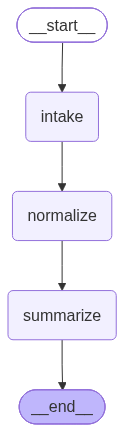

In [ ]:
# Define the shared state
class LinearState(TypedDict):
    incident: str # original problem reported
    normalized: str # cleaned version of the incident text
    summary: str # final summary
    events: Annotated[list[str], operator.add] # list of what steps were completed

# incident = " DC-07 API is DOWN "
# normalized = "dc-07 api is down"
# summary = "Network incident received: dc-07 api is down"
# events = ["intake accepted", "incident normalized", "summary created"]

# events: Annotated[list[str], operator.add]
# This means when different nodes return new events, LangGraph should add/append them together, rather than replacing the previous list.


# It receives the current state and simply records:
#     “The incident has been accepted.”
# It does not change the incident itself.
def linear_intake(state: LinearState) -> dict:
    return {"events": ["intake accepted"]}

# Its job is to clean the incoming incident text.
def linear_normalize(state: LinearState) -> dict:
    normalized = re.sub(r"\s+", " ", state["incident"].strip()).lower()
    return {"normalized": normalized, "events": ["incident normalized"]}
# "  DC-07 inventory API is intermittently unreachable  "
# .strip()
# Removes extra spaces at the beginning and end.
# "DC-07 inventory API is intermittently unreachable"
# re.sub(r"\s+", " ", ...)
# If there are multiple spaces inside the sentence, replace them with one space.
# "DC-07   inventory   API" -> "DC-07 inventory API"

# It creates a final summary using the normalized incident.
def linear_summarize(state: LinearState) -> dict:
    return {
        "summary": f"Network incident received: {state['normalized']}",
        "events": ["summary created"],
    }

linear_builder = StateGraph(LinearState)
linear_builder.add_node("intake", linear_intake)
linear_builder.add_node("normalize", linear_normalize)
linear_builder.add_node("summarize", linear_summarize)
linear_builder.add_edge(START, "intake")
linear_builder.add_edge("intake", "normalize")
linear_builder.add_edge("normalize", "summarize")
linear_builder.add_edge("summarize", END)
linear_graph = linear_builder.compile()

linear_examples = [
    "  DC-07 inventory API is intermittently unreachable  ",
    "STORE-1842 access point reports high channel utilization",
    "Cloud load balancer health checks are timing out",
]
linear_results = []
for example in linear_examples:
    result = linear_graph.invoke({
        "incident":example, "normalized":"", "summary":"", "events":[],
    })
    linear_results.append({
        "input":example.strip(), "normalized":result["normalized"],
        "summary":result["summary"], "node_outputs":" → ".join(result["events"]),
    })

display(pd.DataFrame(linear_results))
show_langgraph_figure(linear_graph, "Figure A — Linear intake workflow")
assert all(row["node_outputs"].endswith("summary created") for row in linear_results)

### Example B — Conditional branch

A branch represents an explicit operating decision. Here the classifier is deterministic and auditable: critical incidents follow an urgent path; other incidents follow the standard path. In production the model may propose severity, but policy validates it before routing.

,severity,route,response,events
0,SEV1,urgent,Open incident bridge and page the on-call lead.,classified as urgent → urgent path
1,SEV2,standard,Queue bounded diagnostic collection.,classified as standard → standard path
2,SEV3,standard,Queue bounded diagnostic collection.,classified as standard → standard path



Figure B — Conditional severity branch


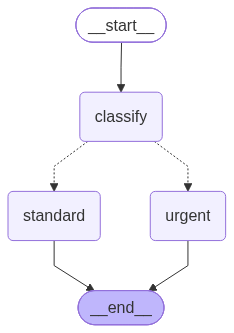

In [17]:
class BranchState(TypedDict):
    severity: str
    route: str
    response: str
    events: Annotated[list[str], operator.add]

def classify_severity(state: BranchState) -> dict:
    route = "urgent" if state["severity"].upper() in {"SEV0", "SEV1"} else "standard"
    return {"route": route, "events": [f"classified as {route}"]}

def urgent_path(state: BranchState) -> dict:
    return {"response": "Open incident bridge and page the on-call lead.", "events": ["urgent path"]}

def standard_path(state: BranchState) -> dict:
    return {"response": "Queue bounded diagnostic collection.", "events": ["standard path"]}

branch_builder = StateGraph(BranchState)
branch_builder.add_node("classify", classify_severity)
branch_builder.add_node("urgent", urgent_path)
branch_builder.add_node("standard", standard_path)
branch_builder.add_edge(START, "classify")
branch_builder.add_conditional_edges("classify", lambda s: s["route"], {"urgent":"urgent", "standard":"standard"})
branch_builder.add_edge("urgent", END)
branch_builder.add_edge("standard", END)
branch_graph = branch_builder.compile()

branch_results = []
for severity in ["SEV1", "SEV2", "SEV3"]:
    result = branch_graph.invoke({"severity":severity, "route":"", "response":"", "events":[]})
    branch_results.append({"severity":severity, "route":result["route"],
                           "response":result["response"], "events":" → ".join(result["events"])})

display(pd.DataFrame(branch_results))
show_langgraph_figure(branch_graph, "Figure B — Conditional severity branch")
assert {row["route"] for row in branch_results} == {"urgent", "standard"}

### Example C — Bounded loop

Agents often need another observation. A safe loop has a measurable completion condition and a hard budget. This example collects at most three samples; it cannot poll forever.

,max_attempts,actual_attempts,samples,enough_evidence,stop_reason
0,2,2,"[95, 90]",False,attempt budget exhausted
1,3,3,"[95, 90, 85]",True,three samples collected
2,5,3,"[95, 90, 85]",True,three samples collected



Figure C — Bounded evidence-collection loop


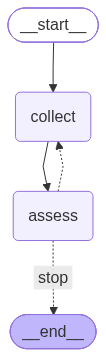

In [ ]:
class LoopState(TypedDict):
    attempts: int # how many samples have already been collected.
    max_attempts: int # maximum number of tries allowed.
    samples: Annotated[list[int], operator.add] # collected monitoring values.
    enough_evidence: bool # whether we have collected enough information.
    stop_reason: str # why the loop stopped.
# attempts = 2
# max_attempts = 3
# samples = [95, 90]
# enough_evidence = False
# stop_reason = "need another sample"

# This node simulates collecting one monitoring sample.
def collect_sample(state: LoopState) -> dict:
    next_attempt = state["attempts"] + 1
    return {"attempts": next_attempt, "samples": [100 - 5 * next_attempt]}

# Assess whether we have enough evidence
def assess_samples(state: LoopState) -> dict:
    enough = len(state["samples"]) >= 3
    exhausted = state["attempts"] >= state["max_attempts"]
    reason = "three samples collected" if enough else ("attempt budget exhausted" if exhausted else "need another sample")
    return {"enough_evidence": enough, "stop_reason": reason}

# Routing decision
def route_loop(state: LoopState) -> str:
    return "stop" if state["enough_evidence"] or state["attempts"] >= state["max_attempts"] else "collect"

loop_builder = StateGraph(LoopState)
loop_builder.add_node("collect", collect_sample)
loop_builder.add_node("assess", assess_samples)
loop_builder.add_edge(START, "collect")
loop_builder.add_edge("collect", "assess")
loop_builder.add_conditional_edges("assess", route_loop, {"collect":"collect", "stop":END})
loop_graph = loop_builder.compile()

loop_results = []
for max_attempts in [2, 3, 5]:
    result = loop_graph.invoke(
        {"attempts":0, "max_attempts":max_attempts, "samples":[],
         "enough_evidence":False, "stop_reason":""},
        config={"recursion_limit":20},
    )
    loop_results.append({"max_attempts":max_attempts, "actual_attempts":result["attempts"],
                         "samples":result["samples"], "enough_evidence":result["enough_evidence"],
                         "stop_reason":result["stop_reason"]})

display(pd.DataFrame(loop_results))
show_langgraph_figure(loop_graph, "Figure C — Bounded evidence-collection loop")
assert loop_results[0]["stop_reason"] == "attempt budget exhausted"
assert loop_results[1]["enough_evidence"] and loop_results[2]["actual_attempts"] == 3

### Example D — Human-in-the-loop interrupt and resume

LangGraph `interrupt()` pauses a node and stores the thread state through a checkpointer. The application displays the JSON-safe approval request. The same `thread_id` is then resumed with `Command(resume=...)`. Code before an interrupt can execute again after resumption, so side effects must occur only after approval and must be idempotent.

,action,requested_approval,interrupt_payload,final_status,events
0,validate a route-policy dry run,True,"{'question': 'Approve dry-run validation?', 'action': 'validate a route-policy dry run'}",DRY_RUN_COMPLETE,proposal created → human decision received → dry-run executed
1,restart a production edge router,False,"{'question': 'Approve dry-run validation?', 'action': 'restart a production edge router'}",CANCELLED,proposal created → human decision received → request cancelled



Figure D — Human approval interrupt and resume


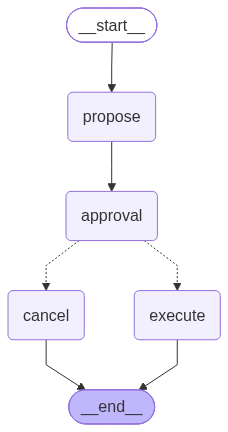

In [ ]:
# AI proposes an action → workflow pauses → human approves/rejects → same workflow resumes → execute or cancel

class IntroApprovalState(TypedDict):
    action: str # what action is being requested.
    approved: bool | None # True, False, or None before the human decides.
    status: str # current workflow status.
    events: Annotated[list[str], operator.add] # history of what happened.
# action = "validate a route-policy dry run"
# approved = None
# status = "NEW"
# events = []

# Proposal node - “The proposed action is ready, but it needs approval.”
def propose_action(state: IntroApprovalState) -> dict:
    return {"status":"PENDING_APPROVAL", "events":["proposal created"]}

# Human approval node - This node is responsible for asking a human.
def request_intro_approval(state: IntroApprovalState) -> dict:
    response = interrupt({"question":"Approve dry-run validation?", "action":state["action"]})
    return {"approved":bool(response.get("approved", False)), "events":["human decision received"]}
# interrupt() tells LangGraph:
# Pause the workflow here and wait for external input.
# The human/application will receive something like:
# Question:
# Approve dry-run validation?

# Action:
# validate a route-policy dry run
# At this moment, the graph stops temporarily.
# It does not continue to execute.

# Execution node - If the human approves, this node runs.
def intro_execute(state: IntroApprovalState) -> dict:
    return {"status":"DRY_RUN_COMPLETE", "events":["dry-run executed"]}

# Cancel node - If the human rejects, this node runs.
def intro_cancel(state: IntroApprovalState) -> dict:
    return {"status":"CANCELLED", "events":["request cancelled"]}

intro_builder = StateGraph(IntroApprovalState)
intro_builder.add_node("propose", propose_action)
intro_builder.add_node("approval", request_intro_approval)
intro_builder.add_node("execute", intro_execute)
intro_builder.add_node("cancel", intro_cancel)
intro_builder.add_edge(START, "propose")
intro_builder.add_edge("propose", "approval")
intro_builder.add_conditional_edges("approval", lambda s: "execute" if s["approved"] else "cancel", {"execute":"execute", "cancel":"cancel"})
intro_builder.add_edge("execute", END)
intro_builder.add_edge("cancel", END)
intro_graph = intro_builder.compile(checkpointer=InMemorySaver())

def run_intro_approval_example(thread_id: str, action: str, approve: bool) -> dict:
    config = {"configurable":{"thread_id":thread_id}}
    paused = intro_graph.invoke(
        {"action":action, "approved":None, "status":"NEW", "events":[]}, config=config,
    )
    payload = paused["__interrupt__"][0].value
    resumed = intro_graph.invoke(Command(resume={"approved":approve}), config=config)
    return {"action":action, "requested_approval":approve, "interrupt_payload":payload,
            "final_status":resumed["status"], "events":" → ".join(resumed["events"])}

intro_results = [
    run_intro_approval_example("day4-intro-approve", "validate a route-policy dry run", True),
    run_intro_approval_example("day4-intro-reject", "restart a production edge router", False),
]
display(pd.DataFrame(intro_results))
show_langgraph_figure(intro_graph, "Figure D — Human approval interrupt and resume")
assert [row["final_status"] for row in intro_results] == ["DRY_RUN_COMPLETE", "CANCELLED"]

### Transition to the operational lab

The next graph combines all four ideas: shared investigation state, conditional routing, a bounded evidence loop, and an explicit recommendation boundary. The node functions remain ordinary Python, which makes them individually testable.

In [20]:
# This block is defining the data structures for the entire investigation. Think of it as deciding: “What information should every evidence item, tool result, decision, hypothesis, and complete incident investigation contain?”

class EvidenceItem(BaseModel):
    evidence_id: str
    category: Literal["incident", "monitoring", "configuration", "change", "knowledge", "topology", "policy"]
    summary: str
    source_id: str
    source_url: str
    observed_at: str | None = None
    live: bool = False


class ToolResult(BaseModel):
    tool: str
    status: Literal["OK", "UNAVAILABLE", "DENIED", "ERROR"]
    summary: str
    evidence: list[EvidenceItem] = Field(default_factory=list)
    missing_context: list[str] = Field(default_factory=list)
    retryable: bool = False


class DecisionRecord(BaseModel):
    step: int
    phase: Literal["OBSERVE", "REASON", "PLAN", "ACT", "VALIDATE", "STOP"]
    decision_summary: str
    selected_tool: str | None = None
    result_status: str | None = None


class Hypothesis(BaseModel):
    hypothesis_id: str
    statement: str
    status: Literal["SUPPORTED", "PARTIALLY_SUPPORTED", "UNSUPPORTED", "UNDETERMINED"]
    supporting_evidence: list[str] = Field(default_factory=list)
    contradicting_evidence: list[str] = Field(default_factory=list)
    validation_needed: list[str] = Field(default_factory=list)


class InvestigationState(BaseModel):
    incident_id: str
    objective: str
    environment: Literal["PUBLIC_LAB", "DEV", "TEST", "PROD"]
    step: int = 0
    status: Literal["NEW", "INVESTIGATING", "VALIDATING", "RECOMMENDING", "COMPLETE", "ESCALATED"] = "NEW"
    evidence: list[EvidenceItem] = Field(default_factory=list)
    decisions: list[DecisionRecord] = Field(default_factory=list)
    hypotheses: list[Hypothesis] = Field(default_factory=list)
    missing_context: list[str] = Field(default_factory=list)
    recommendation: str | None = None
    stop_reason: str | None = None

    def evidence_categories(self) -> set[str]:
        return {item.category for item in self.evidence}

## 2.3 Approved diagnostic tools

Each tool below is read-only and returns typed evidence. `query_monitoring` explicitly reports that no live monitoring source is connected; this is a valid observation that changes the investigation plan.

In [21]:
# Agent asks for information → Tool searches public L3AF data → Tool converts it into structured evidence → Agent uses that evidence for RCA.

# Helper function: convert any record into EvidenceItem
def evidence_from_record(record: dict[str, Any], category: str, summary: str | None = None) -> EvidenceItem:
    return EvidenceItem(
        evidence_id=f"ev-{category}-{record['doc_id']}",
        category=category,
        summary=summary or re.sub(r"\s+", " ", record["content"])[:550],
        source_id=record["doc_id"],
        source_url=record["source_url"],
        live=False,
    )
# a raw GitHub issue may contain:
# {
#     "doc_id": "issue-698",
#     "content": "l3afd_BPFRunning metric reports true...",
#     "source_url": "https://github.com/..."
# }
# This function converts it into a clean structured evidence object.


# This tool searches historical L3AF issues related to the current incident.
def collect_incident_evidence(query: str) -> ToolResult:
    hits = search_corpus(query, top_k=3, source_types={"historical_issue"})
    return ToolResult(
        tool="collect_incident_evidence",
        status="OK",
        summary="Retrieved genuine public L3AF project issues; these are not Walmart production incidents.",
        evidence=[evidence_from_record(hit, "incident") for hit in hits],
    )


def query_monitoring(query: str) -> ToolResult:
    hits = search_corpus(
        query,
        top_k=3,
        source_types={"configuration_repository", "configuration_standard", "historical_issue"},
    )
    return ToolResult(
        tool="query_monitoring",
        status="UNAVAILABLE",
        summary="No authorized live monitoring source is connected. Returned public monitoring-related context only.",
        evidence=[evidence_from_record(hit, "monitoring") for hit in hits],
        missing_context=["authorized live metric series", "load-error logs", "time-aligned alerts"],
    )


def inspect_configuration(section: str) -> ToolResult:
    matches = [r for r in records if r["source_type"] == "configuration_repository" and r["section"].lower() == section.lower()]
    if not matches:
        return ToolResult(tool="inspect_configuration", status="ERROR", summary=f"Unknown sample section: {section}")
    record = matches[0]
    return ToolResult(
        tool="inspect_configuration",
        status="OK",
        summary="Retrieved upstream L3AF sample configuration; it is not a Walmart deployment configuration.",
        evidence=[evidence_from_record(record, "configuration")],
    )


def check_changes(query: str) -> ToolResult:
    record = next(r for r in records if r["source_type"] == "change_records")
    changes = json.loads(record["content"])
    terms = {term.lower() for term in re.findall(r"[A-Za-z0-9_]+", query) if len(term) > 3}
    matches = [c for c in changes if terms & set(re.findall(r"[a-z0-9_]+", c["message"].lower()))][:5]
    summary = json.dumps(matches if matches else changes[:5], indent=2)
    evidence = evidence_from_record(record, "change", summary=summary[:900])
    return ToolResult(
        tool="check_changes",
        status="OK",
        summary="Returned actual public commit metadata; temporal proximity alone does not establish causation.",
        evidence=[evidence],
        missing_context=["authorized deployment/change records for the affected environment"],
    )


def retrieve_knowledge(query: str) -> ToolResult:
    hits = search_corpus(
        query,
        top_k=5,
        source_types={"production_deployment_guide", "operational_runbook", "configuration_standard", "project_readme"},
    )
    return ToolResult(
        tool="retrieve_knowledge",
        status="OK",
        summary="Retrieved public L3AF guidance and documentation.",
        evidence=[evidence_from_record(hit, "knowledge") for hit in hits],
    )


TOOL_REGISTRY: dict[str, Callable[..., ToolResult]] = {
    "collect_incident_evidence": collect_incident_evidence,
    "query_monitoring": query_monitoring,
    "inspect_configuration": inspect_configuration,
    "check_changes": check_changes,
    "retrieve_knowledge": retrieve_knowledge,
}
print("Approved tools:", sorted(TOOL_REGISTRY))

Approved tools: ['check_changes', 'collect_incident_evidence', 'inspect_configuration', 'query_monitoring', 'retrieve_knowledge']


## 2.4 Planner, action selection, and stopping rules

The LangGraph planning node has two implementations behind the same typed contract. Credential-free classroom mode uses a deterministic planner so every learner can inspect and reproduce the path. When `OPENAI_API_KEY` is present and `WAL_NET_ENABLE_LIVE_API=1`, the node uses an OpenAI Structured Output to propose the next tool. In both modes deterministic application code validates the tool name, arguments, permission, state and stopping controls; the offline result is never presented as an LLM result.

The planner stops when required evidence has been attempted and hypotheses have been validated, or when the step budget is exhausted. It never loops indefinitely.

In [22]:
class TroubleshootingGraphState(TypedDict):
    incident_id: str
    objective: str
    environment: str
    step: int
    status: str
    evidence: list[EvidenceItem]
    decisions: list[DecisionRecord]
    hypotheses: list[Hypothesis]
    missing_context: list[str]
    evidence_needed: str | None
    next_tool: str | None
    tool_arguments: dict[str, Any]
    last_tool_status: str | None
    recommendation: str | None
    stop_reason: str | None
    validation_passed: bool

REQUIRED_EVIDENCE_SEQUENCE = ["incident", "monitoring", "configuration", "change", "knowledge"]
LIVE_LANGGRAPH_LLM = bool(os.getenv("OPENAI_API_KEY")) and os.getenv("WAL_NET_ENABLE_LIVE_API") == "1"

class PlannerProposal(BaseModel):
    action: Literal[
        "collect_incident_evidence", "query_monitoring", "inspect_configuration",
        "check_changes", "retrieve_knowledge", "GENERATE_HYPOTHESES", "ESCALATE"
    ]
    query: str | None = None
    section: str | None = None
    rationale: str

def append_decision(state: TroubleshootingGraphState, phase: str, summary: str,
                    tool: str | None = None, result: str | None = None) -> list[DecisionRecord]:
    return state["decisions"] + [DecisionRecord(
        step=state["step"], phase=phase, decision_summary=summary,
        selected_tool=tool, result_status=result,
    )]

def evidence_categories_from_graph(state: TroubleshootingGraphState) -> set[str]:
    return {item.category for item in state["evidence"]}

def observe_node(state: TroubleshootingGraphState) -> dict:
    step = state["step"] + 1
    categories = sorted(evidence_categories_from_graph(state))
    updated = dict(state); updated["step"] = step
    return {
        "step":step,
        "status":"INVESTIGATING",
        "decisions":append_decision(updated, "OBSERVE", f"Evidence categories present: {categories}"),
    }

def reason_node(state: TroubleshootingGraphState) -> dict:
    categories = evidence_categories_from_graph(state)
    needed = next((category for category in REQUIRED_EVIDENCE_SEQUENCE if category not in categories), None)
    summary = f"Next evidence gap: {needed}." if needed else "Required evidence categories have been attempted."
    return {"evidence_needed":needed, "decisions":append_decision(state, "REASON", summary)}

def propose_next_plan(state: TroubleshootingGraphState) -> PlannerProposal:
    deterministic = {
        "incident":PlannerProposal(action="collect_incident_evidence", query=state["objective"], rationale="incident evidence is missing"),
        "monitoring":PlannerProposal(action="query_monitoring", query="BPFRunning metric load error polling samples", rationale="monitoring evidence is missing"),
        "configuration":PlannerProposal(action="inspect_configuration", section="web", rationale="configuration evidence is missing"),
        "change":PlannerProposal(action="check_changes", query="metric monitor BPF program load race", rationale="change evidence is missing"),
        "knowledge":PlannerProposal(action="retrieve_knowledge", query="metrics eBPF program monitoring production diagnostics", rationale="knowledge evidence is missing"),
        None:PlannerProposal(action="GENERATE_HYPOTHESES", rationale="required evidence categories were attempted"),
    }
    if not LIVE_LANGGRAPH_LLM:
        return deterministic[state["evidence_needed"]]

    from openai import OpenAI
    client = OpenAI()
    response = client.responses.parse(
        model=os.getenv("WAL_NET_MODEL", "gpt-5.6-terra"),
        reasoning={"effort":"low"},
        input=[
            {"role":"developer", "content":(
                "You are a read-only NetOps investigation planner. Select exactly one allowed action. "
                "Use the stated evidence gap, never invent tool results, and generate hypotheses only after all categories are attempted."
            )},
            {"role":"user", "content":json.dumps({
                "objective":state["objective"],
                "evidence_present":sorted(evidence_categories_from_graph(state)),
                "evidence_needed":state["evidence_needed"],
                "missing_context":sorted(set(state["missing_context"])),
                "allowed_tools":sorted(troubleshooting_contract.allowed_tools),
            })},
        ],
        text_format=PlannerProposal,
    )
    return response.output_parsed

def plan_node(state: TroubleshootingGraphState) -> dict:
    if state["step"] > troubleshooting_contract.max_steps:
        return {"next_tool":"ESCALATE", "tool_arguments":{},
                "decisions":append_decision(state, "PLAN", "Step budget exceeded; escalate.")}
    proposal = propose_next_plan(state)
    if proposal.action == "ESCALATE":
        return {"next_tool":"ESCALATE", "tool_arguments":{},
                "decisions":append_decision(state, "PLAN", proposal.rationale)}
    if proposal.action == "GENERATE_HYPOTHESES":
        return {"next_tool":None, "tool_arguments":{},
                "decisions":append_decision(state, "PLAN", proposal.rationale)}
    arguments = {"section":proposal.section} if proposal.action == "inspect_configuration" else {"query":proposal.query}
    return {"next_tool":proposal.action, "tool_arguments":arguments,
            "decisions":append_decision(state, "PLAN", f"{proposal.rationale}; arguments={arguments}.", proposal.action)}

def route_after_plan(state: TroubleshootingGraphState) -> str:
    if state["next_tool"] == "ESCALATE":
        return "escalate"
    return "act" if state["next_tool"] else "hypothesize"

def act_node(state: TroubleshootingGraphState) -> dict:
    tool_name = state["next_tool"]
    if tool_name not in troubleshooting_contract.allowed_tools:
        return {"last_tool_status":"DENIED", "stop_reason":f"Tool {tool_name} is not allowed.",
                "decisions":append_decision(state, "ACT", "Policy denied tool.", tool_name, "DENIED")}
    result = TOOL_REGISTRY[tool_name](**state["tool_arguments"])
    existing = {item.evidence_id for item in state["evidence"]}
    evidence = state["evidence"] + [item for item in result.evidence if item.evidence_id not in existing]
    return {
        "evidence":evidence,
        "missing_context":state["missing_context"] + result.missing_context,
        "last_tool_status":result.status,
        "decisions":append_decision(state, "ACT", result.summary, tool_name, result.status),
    }

def validate_observation_node(state: TroubleshootingGraphState) -> dict:
    accepted = len(state["evidence"])
    return {"decisions":append_decision(
        state, "VALIDATE", f"State now contains {accepted} sourced evidence item(s); last status={state['last_tool_status']}."
    )}

def hypothesize_node(state: TroubleshootingGraphState) -> dict:
    evidence_ids = {item.source_id for item in state["evidence"]}
    hypotheses = [
        Hypothesis(
            hypothesis_id="H1",
            statement="The published issue records a mismatch between the BPFRunning metric and a program loading error.",
            status="SUPPORTED" if "l3afd-issue-698" in evidence_ids else "UNDETERMINED",
            supporting_evidence=["l3afd-issue-698"] if "l3afd-issue-698" in evidence_ids else [],
            validation_needed=["confirm affected version and behavior in authorized live logs"],
        ),
        Hypothesis(
            hypothesis_id="H2", statement="The upstream sample polling settings caused the reported mismatch.",
            status="UNSUPPORTED", validation_needed=["sample configuration is not causal evidence", "obtain live configuration"],
        ),
        Hypothesis(
            hypothesis_id="H3", statement="A recent deployment change caused the reported issue.",
            status="UNDETERMINED", validation_needed=["obtain incident-window deployment records"],
        ),
    ]
    return {"hypotheses":hypotheses, "status":"VALIDATING",
            "decisions":append_decision(state, "REASON", "Generated falsifiable hypotheses from evidence IDs.")}

def validate_case_node(state: TroubleshootingGraphState) -> dict:
    has_incident = "incident" in evidence_categories_from_graph(state)
    citations_valid = all(item.source_id and item.source_url for item in state["evidence"])
    passed = has_incident and citations_valid and bool(state["hypotheses"])
    return {"validation_passed":passed, "decisions":append_decision(
        state, "VALIDATE", f"Evidence/hypothesis validation passed={passed}; unresolved gaps={len(set(state['missing_context']))}."
    )}

def recommend_node(state: TroubleshootingGraphState) -> dict:
    recommendation = (
        "Treat the public BPFRunning metric issue as evidence that this metric alone may be insufficient. "
        "An authorized engineer should correlate it with program load/attach logs, confirm the affected version and "
        "live configuration, and review incident-window changes before remediation."
    )
    reason = "Required public evidence attempted; recommendation produced with live-state gaps explicit."
    return {"recommendation":recommendation, "status":"COMPLETE", "stop_reason":reason,
            "decisions":append_decision(state, "STOP", reason)}

def escalate_investigation_node(state: TroubleshootingGraphState) -> dict:
    reason = state.get("stop_reason") or "Evidence validation or workflow budget failed."
    return {"status":"ESCALATED", "stop_reason":reason,
            "decisions":append_decision(state, "STOP", reason)}

troubleshooting_builder = StateGraph(TroubleshootingGraphState)
for name, fn in {
    "observe":observe_node, "reason":reason_node, "plan":plan_node, "act":act_node,
    "validate_observation":validate_observation_node, "hypothesize":hypothesize_node,
    "validate_case":validate_case_node, "recommend":recommend_node,
    "escalate":escalate_investigation_node,
}.items():
    troubleshooting_builder.add_node(name, fn)
troubleshooting_builder.add_edge(START, "observe")
troubleshooting_builder.add_edge("observe", "reason")
troubleshooting_builder.add_edge("reason", "plan")
troubleshooting_builder.add_conditional_edges("plan", route_after_plan,
    {"act":"act", "hypothesize":"hypothesize", "escalate":"escalate"})
troubleshooting_builder.add_edge("act", "validate_observation")
troubleshooting_builder.add_edge("validate_observation", "observe")
troubleshooting_builder.add_edge("hypothesize", "validate_case")
troubleshooting_builder.add_conditional_edges("validate_case",
    lambda s: "recommend" if s["validation_passed"] else "escalate",
    {"recommend":"recommend", "escalate":"escalate"})
troubleshooting_builder.add_edge("recommend", END)
troubleshooting_builder.add_edge("escalate", END)
troubleshooting_graph = troubleshooting_builder.compile()

print("Troubleshooting graph nodes:", sorted(troubleshooting_graph.get_graph().nodes))
print("Troubleshooting graph edges:", len(troubleshooting_graph.get_graph().edges))
print("Planner mode:", "OpenAI structured planner" if LIVE_LANGGRAPH_LLM else "deterministic classroom planner")

Troubleshooting graph nodes: ['__end__', '__start__', 'act', 'escalate', 'hypothesize', 'observe', 'plan', 'reason', 'recommend', 'validate_case', 'validate_observation']
Troubleshooting graph edges: 13
Planner mode: deterministic classroom planner



Mermaid Figure — Public L3AF Evidence Investigator workflow


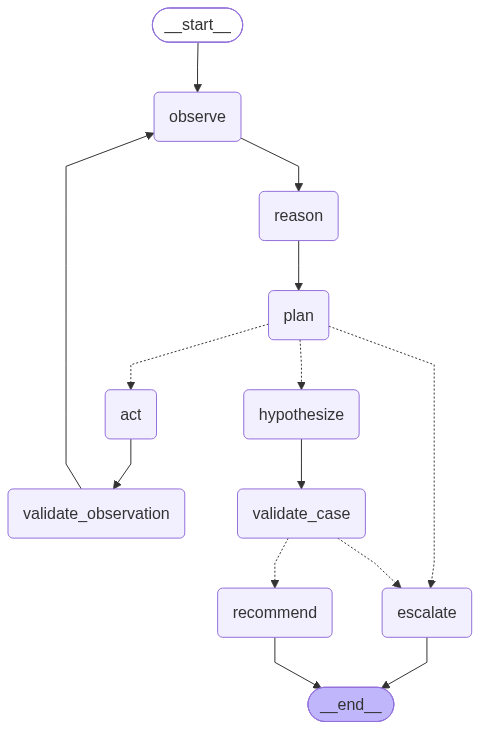

In [23]:
show_langgraph_figure(troubleshooting_graph, "Mermaid Figure — Public L3AF Evidence Investigator workflow")


In [24]:
# Suppose the incident is:
#     “The L3AF BPFRunning metric says the program is running, but traffic is still failing.”

# Then the graph works like this:

# Observe — collect whatever facts are currently available: incident details, monitoring, configuration, recent changes, documentation.
# Reason — analyze the collected evidence and ask, “What is missing? What could be the likely cause?”
# Plan — decide the next best step. The agent may choose to collect more evidence, create hypotheses, or escalate.
# Act → Validate Observation — if more evidence is needed, call a tool such as monitoring/configuration, validate the result, and then loop back to Observe with the new evidence.
# Hypothesize → Validate Case — once enough evidence exists, create possible root causes and check whether they are supported by evidence.
# Recommend — if the case is sufficiently supported, provide a safe recommendation and finish.
# Escalate — if evidence is insufficient, risky, or the agent cannot safely conclude, send it to a human/engineer instead of guessing.

In [ ]:
# Incident:
# BPFRunning = true but program appears unhealthy
#         ↓
# Observe
# Find historical issue + sample configuration
#         ↓
# Reason
# "Live telemetry is missing"
#         ↓
# Plan
# Query monitoring
#         ↓
# Act
# Monitoring tool called
#         ↓
# Validate Observation
# Live monitoring unavailable
#         ↓
# Observe again
# Use the new information
#         ↓
# Reason
# Historical issue #698 strongly matches symptom
#         ↓
# Plan
# Generate hypothesis
#         ↓
# Hypothesize
# "Metric may be stale/misleading after load failure"
#         ↓
# Validate Case
# Public evidence supports it,
# but production logs are unavailable
#         ↓
# Recommend
# "Validate actual loaded eBPF programs and logs
# before taking remediation action"
#         ↓
# END

# Hands-on Lab 8 — Build an AI Network Troubleshooting Agent

## Mission

Build a tool-enabled agent that autonomously determines:

- what evidence is required;
- which diagnostic tool to invoke;
- what additional context is missing;
- which hypotheses are supported;
- what action should be recommended.

### Public issue scenario

Investigate L3AF issue **#698**, which reports that `l3afd_BPFRunning` can report true while a program-loading error occurs. The lab must not infer a Walmart production incident or query a live environment.

Status: COMPLETE
Stop reason: Required public evidence attempted; recommendation produced with live-state gaps explicit.
Recommendation: Treat the public BPFRunning metric issue as evidence that this metric alone may be insufficient. An authorized engineer should correlate it with program load/attach logs, confirm the affected version and live configuration, and review incident-window changes before remediation.


,scenario,status,steps,evidence_items,hypotheses,stop_reason
0,normal evidence budget,COMPLETE,6,13,3,Required public evidence attempted; recommendation produced with live-state gaps explicit.
1,budget already exhausted,ESCALATED,11,0,0,Evidence validation or workflow budget failed.



Figure E — Lab 8 troubleshooting agent


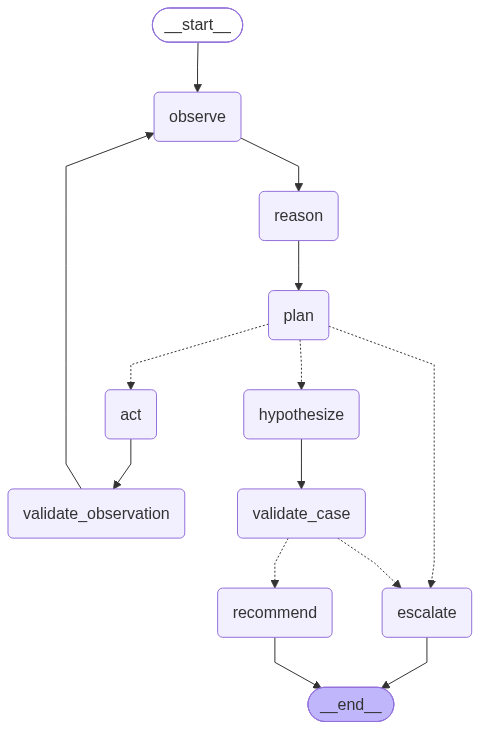

In [25]:
lab8_initial: TroubleshootingGraphState = {
    "incident_id":"PUBLIC-L3AF-ISSUE-698",
    "objective":"Investigate the public report that l3afd_BPFRunning is true while an eBPF program loading error occurs.",
    "environment":"PUBLIC_LAB",
    "step":0, "status":"NEW", "evidence":[], "decisions":[], "hypotheses":[],
    "missing_context":[], "evidence_needed":None, "next_tool":None, "tool_arguments":{},
    "last_tool_status":None, "recommendation":None, "stop_reason":None,
    "validation_passed":False,
}
lab8_graph_result = troubleshooting_graph.invoke(lab8_initial, config={"recursion_limit":50})
lab8_result = InvestigationState(
    incident_id=lab8_graph_result["incident_id"],
    objective=lab8_graph_result["objective"],
    environment=lab8_graph_result["environment"],
    step=lab8_graph_result["step"],
    status=lab8_graph_result["status"],
    evidence=lab8_graph_result["evidence"],
    decisions=lab8_graph_result["decisions"],
    hypotheses=lab8_graph_result["hypotheses"],
    missing_context=lab8_graph_result["missing_context"],
    recommendation=lab8_graph_result["recommendation"],
    stop_reason=lab8_graph_result["stop_reason"],
)

print("Status:", lab8_result.status)
print("Stop reason:", lab8_result.stop_reason)
print("Recommendation:", lab8_result.recommendation)

budget_limited_initial = dict(lab8_initial)
budget_limited_initial.update({"incident_id":"PUBLIC-L3AF-BUDGET-DEMO", "step":10})
budget_limited_graph_result = troubleshooting_graph.invoke(
    budget_limited_initial, config={"recursion_limit":10}
)

lab8_scenario_report = pd.DataFrame([
    {
        "scenario":"normal evidence budget",
        "status":lab8_graph_result["status"],
        "steps":lab8_graph_result["step"],
        "evidence_items":len(lab8_graph_result["evidence"]),
        "hypotheses":len(lab8_graph_result["hypotheses"]),
        "stop_reason":lab8_graph_result["stop_reason"],
    },
    {
        "scenario":"budget already exhausted",
        "status":budget_limited_graph_result["status"],
        "steps":budget_limited_graph_result["step"],
        "evidence_items":len(budget_limited_graph_result["evidence"]),
        "hypotheses":len(budget_limited_graph_result["hypotheses"]),
        "stop_reason":budget_limited_graph_result["stop_reason"],
    },
])
display(lab8_scenario_report)
show_langgraph_figure(troubleshooting_graph, "Figure E — Lab 8 troubleshooting agent")
assert set(lab8_scenario_report.status) == {"COMPLETE", "ESCALATED"}

In [26]:
decision_df = pd.DataFrame([item.model_dump() for item in lab8_result.decisions])
evidence_df = pd.DataFrame([item.model_dump() for item in lab8_result.evidence])
hypothesis_df = pd.DataFrame([item.model_dump() for item in lab8_result.hypotheses])

display(decision_df)
display(evidence_df[["category", "source_id", "live", "summary", "source_url"]])
display(hypothesis_df)
print("Missing live context:", sorted(set(lab8_result.missing_context)))

,step,phase,decision_summary,selected_tool,result_status
0,1,OBSERVE,Evidence categories present: [],NaN,NaN
1,1,REASON,Next evidence gap: incident.,NaN,NaN
2,1,PLAN,incident evidence is missing; arguments={'query': 'Investigate the public report that l3afd_BPFRunning is true while...,collect_incident_evidence,NaN
3,1,ACT,Retrieved genuine public L3AF project issues; these are not Walmart production incidents.,collect_incident_evidence,OK
4,1,VALIDATE,State now contains 3 sourced evidence item(s); last status=OK.,NaN,NaN
5,2,OBSERVE,Evidence categories present: ['incident'],NaN,NaN
6,2,REASON,Next evidence gap: monitoring.,NaN,NaN
7,2,PLAN,monitoring evidence is missing; arguments={'query': 'BPFRunning metric load error polling samples'}.,query_monitoring,NaN
8,2,ACT,No authorized live monitoring source is connected. Returned public monitoring-related context only.,query_monitoring,UNAVAILABLE
9,2,VALIDATE,State now contains 6 sourced evidence item(s); last status=UNAVAILABLE.,NaN,NaN


,category,source_id,live,summary,source_url
0,incident,l3afd-issue-698,False,"{ ""number"": 698, ""state"": ""closed"", ""title"": ""l3afd_BPFRunning metric reports true incase of ebpf_program loading er...",https://github.com/l3af-project/l3afd/issues/698
1,incident,l3afd-issue-523,False,"{ ""number"": 523, ""state"": ""closed"", ""title"": ""Add metrics to count ebpf program loading failure errors"", ""labels"": [...",https://github.com/l3af-project/l3afd/issues/523
2,incident,l3afd-issue-637,False,"{ ""number"": 637, ""state"": ""closed"", ""title"": ""Remove stale metric reporting on eBPF program unload"", ""labels"": [], ""...",https://github.com/l3af-project/l3afd/issues/637
3,monitoring,l3afd-config-web,False,"{ ""metrics-addr"": ""localhost:8898"", ""ebpf-poll-interval"": ""30s"", ""n-metric-samples"": ""20"" }",https://github.com/l3af-project/l3afd/blob/main/config/l3afd.cfg
4,monitoring,configuration_standard-05,False,| FieldName | Default | Description | Required | |--------------------| ------------- | --------------- |----------|...,https://github.com/l3af-project/l3afd/blob/main/docs/configdoc.md
5,monitoring,l3afd-issue-698,False,"{ ""number"": 698, ""state"": ""closed"", ""title"": ""l3afd_BPFRunning metric reports true incase of ebpf_program loading er...",https://github.com/l3af-project/l3afd/issues/698
6,configuration,l3afd-config-web,False,"{ ""metrics-addr"": ""localhost:8898"", ""ebpf-poll-interval"": ""30s"", ""n-metric-samples"": ""20"" }",https://github.com/l3af-project/l3afd/blob/main/config/l3afd.cfg
7,change,l3afd-recent-public-changes,False,"[\n {\n ""sha"": ""7d5dbf6f8ad32d4008ac659d9bd860e3fa101979"",\n ""date"": ""2026-07-23T06:51:22Z"",\n ""author"": ""...",https://github.com/l3af-project/l3afd/commits/main
8,knowledge,production_deployment_guide-02,False,This guide lists recommendations on how to run l3afd in a production environment. Please see [l3afd.cfg](../config/l...,https://github.com/l3af-project/l3afd/blob/main/docs/prod-deploy-guide.md
9,knowledge,configuration_standard-05,False,| FieldName | Default | Description | Required | |--------------------| ------------- | --------------- |----------|...,https://github.com/l3af-project/l3afd/blob/main/docs/configdoc.md


,hypothesis_id,statement,status,supporting_evidence,contradicting_evidence,validation_needed
0,H1,The published issue records a mismatch between the BPFRunning metric and a program loading error.,SUPPORTED,[l3afd-issue-698],[],[confirm affected version and behavior in authorized live logs]
1,H2,The upstream sample polling settings caused the reported mismatch.,UNSUPPORTED,[],[],"[sample configuration is not causal evidence, obtain live configuration]"
2,H3,A recent deployment change caused the reported issue.,UNDETERMINED,[],[],[obtain incident-window deployment records]


Missing live context: ['authorized deployment/change records for the affected environment', 'authorized live metric series', 'load-error logs', 'time-aligned alerts']


In [27]:
assert lab8_result.status == "COMPLETE"
assert {"incident", "monitoring", "configuration", "change", "knowledge"}.issubset(lab8_result.evidence_categories())
assert all(not item.live for item in lab8_result.evidence)
assert any(h.hypothesis_id == "H1" and h.status == "SUPPORTED" for h in lab8_result.hypotheses)
assert any(h.status == "UNDETERMINED" for h in lab8_result.hypotheses)
assert lab8_result.missing_context
assert "authorized engineer" in lab8_result.recommendation
print("✓ Lab 8 acceptance tests passed")

✓ Lab 8 acceptance tests passed


# Module 3 — Agent Memory, State & Context Management

## 3.1 Four different things called “memory”

| Type | Purpose | Example | Risk |
|---|---|---|---|
| Short-term memory | current reasoning window | latest tool results | context overflow |
| Persistent memory | survive process/session restart | saved incident state | stale or over-broad access |
| Workflow state | authoritative progress | completed steps, approvals | invalid transitions |
| Incident context | scoped facts for one case | evidence, time window, entities | cross-incident contamination |

A vector store is not automatically memory, and conversation history is not automatically state. Persist only what has a defined owner, scope, retention policy, access control, source, timestamp, and invalidation rule.

### Plain-language operational examples

- **Short-term memory:** during one investigation the agent remembers that DNS already succeeded, so it does not repeat the same lookup. It should disappear when the incident thread ends.
- **Persistent memory:** a resolved incident pattern—reviewed by an engineer—is saved so a future incident can retrieve it. Persistent does not mean permanently trusted; ownership and expiry still apply.
- **Workflow state:** the incident is currently `VALIDATING`, four tools have completed, and approval is still absent. This is control-plane truth, not conversational prose.
- **Incident context:** affected site, services, incident window, evidence IDs and current hypotheses. It must never leak into a different incident or environment.
- **Memory boundary:** a store-network agent may read sanitized telemetry but not payment-network configuration. The boundary is enforced by identity and authorization, not by asking the model to behave.
- **Stale-context risk:** yesterday’s interface state says “up,” but a remediation decision is needed now. The agent must re-query the source rather than reuse the old observation.
- **Multi-step state management:** after each node, save what completed, what changed, what remains unknown and where execution may resume. This makes retries and human review predictable.

In [28]:
# Short-term memory
# → Don't check DNS again.

# Persistent memory
# → Similar incidents previously involved channel congestion.

# Workflow state
# → Currently validating the hypothesis.

# Incident context
# → This investigation concerns STORE-1842 / AP-07 only.

In [29]:
# A production Agentic AI system should not treat all remembered information as one giant “memory.” Working memory, reusable knowledge, workflow progress, and incident-specific facts have different lifetimes, permissions, and risks.

## 3.2 Memory boundaries and stale context risks

Enterprise rules:

- never persist hidden credentials, raw secrets, or unnecessary personal data;
- isolate tenant, environment, incident, and user scopes;
- preserve source IDs and observation timestamps;
- mark model-generated summaries as derived, not observed;
- invalidate live observations after a domain-specific TTL;
- re-query source-of-truth systems before risky decisions;
- version the state schema and migration path;
- retain an append-only decision/action audit log;
- clear or archive state at incident closure according to policy.

In [ ]:
# The AI troubleshooting agent can save the current investigation state to a database, later reload it, and safely continue — but only if the environment and source data still match.

class MemoryEnvelope(BaseModel):
    schema_version: str = "1.0"
    incident_id: str
    environment: str
    saved_at: datetime
    source_manifest_hash: str
    state_json: str
# Saved Memory
# │
# ├── Which incident?
# ├── Which environment?
# ├── When saved?
# ├── Which source-data version?
# └── Actual investigation state


# Create the SQLite storage class
class SQLiteIncidentStore:
    def __init__(self, path: Path):
        self.path = path
        with sqlite3.connect(self.path) as conn:
            conn.execute(
                '''CREATE TABLE IF NOT EXISTS incident_state (
                       incident_id TEXT PRIMARY KEY,
                       environment TEXT NOT NULL,
                       saved_at TEXT NOT NULL,
                       source_manifest_hash TEXT NOT NULL,
                       state_json TEXT NOT NULL
                   )'''
            )

    def save(self, state: InvestigationState) -> None:
        envelope = MemoryEnvelope(
            incident_id=state.incident_id,
            environment=state.environment,
            saved_at=datetime.now(timezone.utc),
            source_manifest_hash=manifest["corpus_sha256"],
            state_json=state.model_dump_json(),
        )
        with sqlite3.connect(self.path) as conn:
            conn.execute(
                '''INSERT OR REPLACE INTO incident_state
                   (incident_id, environment, saved_at, source_manifest_hash, state_json)
                   VALUES (?, ?, ?, ?, ?)''',
                (
                    envelope.incident_id,
                    envelope.environment,
                    envelope.saved_at.isoformat(),
                    envelope.source_manifest_hash,
                    envelope.state_json,
                ),
            )

    def load(self, incident_id: str, environment: str) -> InvestigationState:
        with sqlite3.connect(self.path) as conn:
            row = conn.execute(
                "SELECT environment, source_manifest_hash, state_json FROM incident_state WHERE incident_id = ?",
                (incident_id,),
            ).fetchone()
        if not row:
            raise KeyError(incident_id)
        if row[0] != environment:
            raise PermissionError("Environment scope mismatch")
        if row[1] != manifest["corpus_sha256"]:
            raise RuntimeError("Source manifest changed; revalidate stored state")
        return InvestigationState.model_validate_json(row[2])

In [31]:
with tempfile.TemporaryDirectory(prefix="session4-memory-") as temp_dir:
    store_path = Path(temp_dir) / "incident_state.sqlite"
    store = SQLiteIncidentStore(store_path)
    store.save(lab8_result)
    restored = SQLiteIncidentStore(store_path).load("PUBLIC-L3AF-ISSUE-698", "PUBLIC_LAB")
    assert restored == lab8_result
    print("✓ State survived a new database connection and retained incident/environment boundaries")
    print("Temporary store:", store_path)

✓ State survived a new database connection and retained incident/environment boundaries
Temporary store: /var/folders/5g/9xpg7d6d4114s98tv10y9rgm0000gn/T/session4-memory-n4nld04y/incident_state.sqlite


In [32]:
class FreshnessPolicy(BaseModel):
    live_observation_ttl: timedelta = timedelta(minutes=5)
    document_review_ttl: timedelta = timedelta(days=90)

    def is_fresh(self, observed_at: datetime, *, live: bool, now: datetime) -> bool:
        ttl = self.live_observation_ttl if live else self.document_review_ttl
        return now - observed_at <= ttl

freshness_policy = FreshnessPolicy()
manifest_time = datetime.fromisoformat(manifest["created_at"])
check_time = manifest_time + timedelta(minutes=1)
print("Public corpus fresh at validation time:", freshness_policy.is_fresh(manifest_time, live=False, now=check_time))
print("Live results would require a much shorter TTL and re-query before action.")

Public corpus fresh at validation time: True
Live results would require a much shorter TTL and re-query before action.


# Module 4 — Multi-Agent Systems for Network & Infrastructure Operations

## 4.1 Specialization by authority, not by job-title theater

An agent boundary is useful when it separates at least one of these: data authority, tool permissions, context, evaluation criteria, failure domain, ownership, or scaling behavior. Ten differently named prompts with identical access are not a robust multi-agent architecture.

In [33]:
class AgentSpec(BaseModel):
    name: str
    mission: str
    allowed_tools: list[str]
    data_scope: str
    permission: Literal["READ_ONLY", "RECOMMEND_ONLY", "APPROVAL_REQUIRED"]
    output_contract: str
    failure_behavior: str


agent_specs = [
    AgentSpec(name="Incident Coordinator Agent", mission="Own case state, budget, delegation, and final escalation.", allowed_tools=["delegate", "read_state"], data_scope="one incident", permission="READ_ONLY", output_contract="coordination plan", failure_behavior="stop and escalate"),
    AgentSpec(name="Monitoring/Telemetry Agent", mission="Query time-scoped signals and describe observation quality.", allowed_tools=["query_monitoring"], data_scope="approved metrics/logs", permission="READ_ONLY", output_contract="observations + gaps", failure_behavior="return unavailable; never synthesize telemetry"),
    AgentSpec(name="Topology Agent", mission="Resolve dependencies, paths, and blast-radius candidates.", allowed_tools=["query_topology"], data_scope="authorized topology", permission="READ_ONLY", output_contract="nodes/edges + source", failure_behavior="mark topology unknown"),
    AgentSpec(name="Configuration Agent", mission="Retrieve and compare approved configuration evidence.", allowed_tools=["inspect_configuration"], data_scope="scoped config", permission="READ_ONLY", output_contract="config evidence/diff", failure_behavior="do not infer missing config"),
    AgentSpec(name="Knowledge/RAG Agent", mission="Retrieve standards, runbooks, and related issue knowledge.", allowed_tools=["retrieve_knowledge"], data_scope="approved corpus", permission="READ_ONLY", output_contract="cited passages", failure_behavior="abstain below retrieval threshold"),
    AgentSpec(name="RCA Agent", mission="Generate and rank falsifiable hypotheses from evidence.", allowed_tools=["read_evidence"], data_scope="incident evidence", permission="RECOMMEND_ONLY", output_contract="support/contradiction matrix", failure_behavior="return undetermined"),
    AgentSpec(name="Security/Policy Agent", mission="Evaluate data and action policy before recommendations advance.", allowed_tools=["retrieve_policy", "evaluate_policy"], data_scope="policy + proposal", permission="READ_ONLY", output_contract="policy decision", failure_behavior="fail closed"),
    AgentSpec(name="Remediation Agent", mission="Produce bounded remediation and rollback plans.", allowed_tools=["draft_remediation"], data_scope="validated hypothesis", permission="RECOMMEND_ONLY", output_contract="plan + rollback", failure_behavior="escalate if rollback absent"),
    AgentSpec(name="Validation Agent", mission="Test evidence, plan, and post-action invariants.", allowed_tools=["validate_evidence", "validate_plan"], data_scope="state + policy", permission="READ_ONLY", output_contract="pass/fail + reasons", failure_behavior="block progression"),
    AgentSpec(name="Incident Documentation Agent", mission="Create an auditable incident narrative.", allowed_tools=["read_state"], data_scope="approved final state", permission="READ_ONLY", output_contract="cited report", failure_behavior="publish draft only"),
]
display(pd.DataFrame([spec.model_dump() for spec in agent_specs]))

,name,mission,allowed_tools,data_scope,permission,output_contract,failure_behavior
0,Incident Coordinator Agent,"Own case state, budget, delegation, and final escalation.","[delegate, read_state]",one incident,READ_ONLY,coordination plan,stop and escalate
1,Monitoring/Telemetry Agent,Query time-scoped signals and describe observation quality.,[query_monitoring],approved metrics/logs,READ_ONLY,observations + gaps,return unavailable; never synthesize telemetry
2,Topology Agent,"Resolve dependencies, paths, and blast-radius candidates.",[query_topology],authorized topology,READ_ONLY,nodes/edges + source,mark topology unknown
3,Configuration Agent,Retrieve and compare approved configuration evidence.,[inspect_configuration],scoped config,READ_ONLY,config evidence/diff,do not infer missing config
4,Knowledge/RAG Agent,"Retrieve standards, runbooks, and related issue knowledge.",[retrieve_knowledge],approved corpus,READ_ONLY,cited passages,abstain below retrieval threshold
5,RCA Agent,Generate and rank falsifiable hypotheses from evidence.,[read_evidence],incident evidence,RECOMMEND_ONLY,support/contradiction matrix,return undetermined
6,Security/Policy Agent,Evaluate data and action policy before recommendations advance.,"[retrieve_policy, evaluate_policy]",policy + proposal,READ_ONLY,policy decision,fail closed
7,Remediation Agent,Produce bounded remediation and rollback plans.,[draft_remediation],validated hypothesis,RECOMMEND_ONLY,plan + rollback,escalate if rollback absent
8,Validation Agent,"Test evidence, plan, and post-action invariants.","[validate_evidence, validate_plan]",state + policy,READ_ONLY,pass/fail + reasons,block progression
9,Incident Documentation Agent,Create an auditable incident narrative.,[read_state],approved final state,READ_ONLY,cited report,publish draft only


# Hands-on Lab 9 — Design an Agentic NOC

## Team challenge

Design a multi-agent incident-management workflow and justify:

**Agent Boundaries → Tools → Handoffs → Permissions → Failure Handling → Human Controls**

Teams receive 12 minutes to design, 5 minutes to attack another team’s design, and 3 minutes to revise. The architecture passes only if every boundary has an operational reason and every failure has an owner.

In [34]:
lab9_canvas = pd.DataFrame(
    [
        {
            "agent": spec.name,
            "boundary_reason": spec.data_scope,
            "tools": ", ".join(spec.allowed_tools),
            "permission": spec.permission,
            "handoff_output": spec.output_contract,
            "failure_handling": spec.failure_behavior,
            "human_control": "required before any write" if spec.permission != "READ_ONLY" else "review on escalation",
        }
        for spec in agent_specs
    ]
)
display(lab9_canvas)

,agent,boundary_reason,tools,permission,handoff_output,failure_handling,human_control
0,Incident Coordinator Agent,one incident,"delegate, read_state",READ_ONLY,coordination plan,stop and escalate,review on escalation
1,Monitoring/Telemetry Agent,approved metrics/logs,query_monitoring,READ_ONLY,observations + gaps,return unavailable; never synthesize telemetry,review on escalation
2,Topology Agent,authorized topology,query_topology,READ_ONLY,nodes/edges + source,mark topology unknown,review on escalation
3,Configuration Agent,scoped config,inspect_configuration,READ_ONLY,config evidence/diff,do not infer missing config,review on escalation
4,Knowledge/RAG Agent,approved corpus,retrieve_knowledge,READ_ONLY,cited passages,abstain below retrieval threshold,review on escalation
5,RCA Agent,incident evidence,read_evidence,RECOMMEND_ONLY,support/contradiction matrix,return undetermined,required before any write
6,Security/Policy Agent,policy + proposal,"retrieve_policy, evaluate_policy",READ_ONLY,policy decision,fail closed,review on escalation
7,Remediation Agent,validated hypothesis,draft_remediation,RECOMMEND_ONLY,plan + rollback,escalate if rollback absent,required before any write
8,Validation Agent,state + policy,"validate_evidence, validate_plan",READ_ONLY,pass/fail + reasons,block progression,review on escalation
9,Incident Documentation Agent,approved final state,read_state,READ_ONLY,cited report,publish draft only,review on escalation


## LangGraph-controlled remediation workflow

The graph below owns the full lifecycle:

**Recommend → Evaluate policy → Interrupt for approval when required → Dry-run execute → Validate → Complete or rollback/escalate**

Important separation: LangGraph coordinates state and transitions; the deterministic policy decides what route is legal; the human supplies approval; the dry-run executor represents a separately privileged production service. No node receives unrestricted infrastructure credentials.

In [36]:
class RemediationProposal(BaseModel):
    model_config = ConfigDict(extra="forbid")

    proposal_id: str
    action: str
    target: str
    environment: Literal["PUBLIC_LAB", "DEV", "TEST", "PROD", "UNKNOWN"]
    operation: Literal["READ", "WRITE", "RESTART", "DELETE", "DEPLOY"]
    blast_radius: Literal["NONE", "SINGLE_COMPONENT", "MULTI_COMPONENT", "UNKNOWN"]
    reversible: bool
    evidence_ids: list[str]
    validation_plan: list[str]
    rollback_plan: list[str]

    @model_validator(mode="after")
    def writes_need_rollback(self):
        if self.operation in {"WRITE", "RESTART", "DELETE", "DEPLOY"} and not self.rollback_plan:
            raise ValueError("State-changing proposals require a rollback/escalation plan")
        return self


class PolicyDecision(BaseModel):
    decision: Literal["ALLOW_READ_ONLY", "RECOMMEND_ONLY", "REQUIRE_HUMAN_APPROVAL", "DENY", "ESCALATE"]
    reasons: list[str]
    can_execute: bool = False


def evaluate_remediation_policy(proposal: RemediationProposal) -> PolicyDecision:
    if proposal.operation == "READ":
        return PolicyDecision(decision="ALLOW_READ_ONLY", reasons=["read-only operation; target authorization still required"])
    if "public repository" in proposal.target.lower() and proposal.environment == "PROD":
        return PolicyDecision(
            decision="DENY",
            reasons=["public production guide recommends a validated private mirror/local repository", "public lab has no execution authority"],
        )
    if proposal.operation == "DELETE":
        return PolicyDecision(decision="ESCALATE", reasons=["destructive operation", "requires specialist review and independent recovery validation"])
    if proposal.environment in {"PROD", "UNKNOWN"} or proposal.blast_radius == "UNKNOWN":
        return PolicyDecision(decision="REQUIRE_HUMAN_APPROVAL", reasons=["production/unknown scope", "exact plan and rollback require human authorization"])
    return PolicyDecision(decision="RECOMMEND_ONLY", reasons=["public classroom workflow has no infrastructure executor"])


Figure G — Controlled remediation and human approval


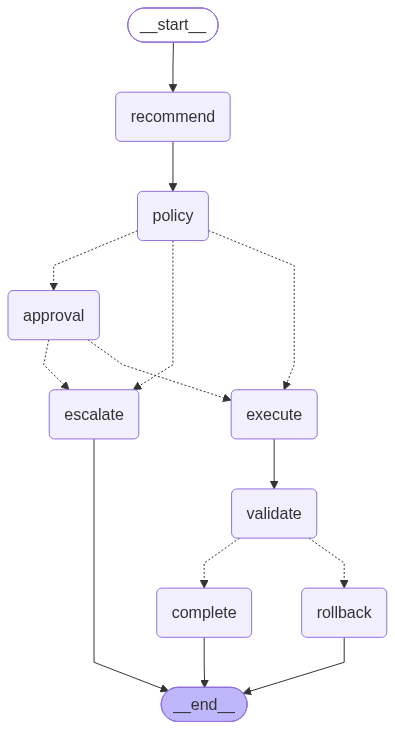

In [37]:
class ControlledRemediationState(TypedDict):
    proposal: RemediationProposal
    policy: PolicyDecision | None
    approved: bool | None
    execution_result: dict[str, Any]
    validation_passed: bool
    final_status: str
    audit: Annotated[list[str], operator.add]

def remediation_recommend_node(state: ControlledRemediationState) -> dict:
    proposal = state["proposal"]
    return {"audit":[f"RECOMMEND {proposal.proposal_id}: {proposal.action}"]}

def remediation_policy_node(state: ControlledRemediationState) -> dict:
    decision = evaluate_remediation_policy(state["proposal"])
    return {"policy":decision, "audit":[f"POLICY {decision.decision}: {'; '.join(decision.reasons)}"]}

def route_remediation_policy(state: ControlledRemediationState) -> str:
    decision = state["policy"].decision
    if decision == "ALLOW_READ_ONLY":
        return "execute"
    if decision == "REQUIRE_HUMAN_APPROVAL":
        return "approval"
    return "escalate"

def remediation_approval_node(state: ControlledRemediationState) -> dict:
    proposal = state["proposal"]
    response = interrupt({
        "question":"Approve this exact dry-run proposal?",
        "proposal_id":proposal.proposal_id,
        "action":proposal.action,
        "target":proposal.target,
        "environment":proposal.environment,
        "blast_radius":proposal.blast_radius,
        "rollback_plan":proposal.rollback_plan,
    })
    approved = bool(response.get("approved", False))
    return {"approved":approved, "audit":[f"APPROVAL {'GRANTED' if approved else 'REJECTED'}"]}

def route_after_human(state: ControlledRemediationState) -> str:
    return "execute" if state["approved"] else "escalate"

def remediation_execute_node(state: ControlledRemediationState) -> dict:
    proposal = state["proposal"]
    decision = state["policy"]
    if decision.decision == "REQUIRE_HUMAN_APPROVAL" and not state["approved"]:
        result = {"status":"BLOCKED", "executed":False, "message":"Approval missing."}
    else:
        result = {
            "status":"DRY_RUN_COMPLETE",
            "executed":False,
            "message":f"Validated execution envelope for {proposal.proposal_id}; classroom mode performed no change.",
        }
    return {"execution_result":result, "audit":[f"EXECUTE {result['status']} (executed={result['executed']})"]}

def remediation_validate_node(state: ControlledRemediationState) -> dict:
    proposal = state["proposal"]
    result = state["execution_result"]
    rollback_ready = proposal.operation == "READ" or bool(proposal.rollback_plan)
    passed = result.get("status") == "DRY_RUN_COMPLETE" and not result.get("executed") and rollback_ready
    return {"validation_passed":passed,
            "audit":[f"VALIDATE passed={passed}; rollback_ready={rollback_ready}"]}

def route_after_validation(state: ControlledRemediationState) -> str:
    return "complete" if state["validation_passed"] else "rollback"

def remediation_complete_node(state: ControlledRemediationState) -> dict:
    return {"final_status":"VALIDATED_DRY_RUN", "audit":["COMPLETE: validation invariants passed"]}

def remediation_rollback_node(state: ControlledRemediationState) -> dict:
    return {"final_status":"ROLLBACK_OR_ESCALATE", "audit":["ROLLBACK/ESCALATE: validation failed"]}

def remediation_escalate_node(state: ControlledRemediationState) -> dict:
    reason = state["policy"].decision if state.get("policy") else "missing policy"
    return {"final_status":"ESCALATED", "audit":[f"ESCALATE: {reason}"]}

remediation_builder = StateGraph(ControlledRemediationState)
for name, fn in {
    "recommend":remediation_recommend_node, "policy":remediation_policy_node,
    "approval":remediation_approval_node, "execute":remediation_execute_node,
    "validate":remediation_validate_node, "complete":remediation_complete_node,
    "rollback":remediation_rollback_node, "escalate":remediation_escalate_node,
}.items():
    remediation_builder.add_node(name, fn)
remediation_builder.add_edge(START, "recommend")
remediation_builder.add_edge("recommend", "policy")
remediation_builder.add_conditional_edges("policy", route_remediation_policy,
    {"execute":"execute", "approval":"approval", "escalate":"escalate"})
remediation_builder.add_conditional_edges("approval", route_after_human,
    {"execute":"execute", "escalate":"escalate"})
remediation_builder.add_edge("execute", "validate")
remediation_builder.add_conditional_edges("validate", route_after_validation,
    {"complete":"complete", "rollback":"rollback"})
remediation_builder.add_edge("complete", END)
remediation_builder.add_edge("rollback", END)
remediation_builder.add_edge("escalate", END)
remediation_graph = remediation_builder.compile(checkpointer=InMemorySaver())

def run_remediation_scenario(proposal: RemediationProposal, human_approval: bool = False) -> dict:
    config = {"configurable":{"thread_id":f"day4-{proposal.proposal_id}-{uuid.uuid4()}"}}
    initial: ControlledRemediationState = {
        "proposal":proposal, "policy":None, "approved":None, "execution_result":{},
        "validation_passed":False, "final_status":"NEW", "audit":[],
    }
    result = remediation_graph.invoke(initial, config=config)
    if "__interrupt__" in result:
        print(f"{proposal.proposal_id} interrupt:", result["__interrupt__"][0].value)
        result = remediation_graph.invoke(Command(resume={"approved":human_approval}), config=config)
    return result

show_langgraph_figure(remediation_graph, "Figure G — Controlled remediation and human approval")

# Hands-on Lab 10 — Should the Agent Execute? (LangGraph)

Evaluate each public-source scenario through:

**Recommend → Approve → Execute → Validate → Rollback/Escalate**

Every proposal runs through the compiled LangGraph workflow. Approval-required proposals pause through `interrupt()` and resume through `Command`. The lab’s answer to “execute” is always a dry-run status; learners judge what a real controlled system would require.

In [38]:
lab10_proposals = [
    RemediationProposal(
        proposal_id="P1",
        action="Read the configured metrics endpoint",
        target="authorized l3afd configuration",
        environment="PUBLIC_LAB",
        operation="READ",
        blast_radius="NONE",
        reversible=True,
        evidence_ids=["l3afd-config-web"],
        validation_plan=["confirm returned section has source attribution"],
        rollback_plan=[],
    ),
    RemediationProposal(
        proposal_id="P2",
        action="Enable the eBPF chain debug API",
        target="l3afd instance",
        environment="PROD",
        operation="WRITE",
        blast_radius="SINGLE_COMPONENT",
        reversible=True,
        evidence_ids=["production_deployment_guide-02", "l3afd-config-ebpf-chain-debug"],
        validation_plan=["verify localhost-only binding", "verify debug exposure is disabled after investigation"],
        rollback_plan=["restore prior configuration", "confirm endpoint is disabled"],
    ),
    RemediationProposal(
        proposal_id="P3",
        action="Perform graceful restart",
        target="l3afd instance",
        environment="UNKNOWN",
        operation="RESTART",
        blast_radius="UNKNOWN",
        reversible=True,
        evidence_ids=["operational_runbook-05"],
        validation_plan=["validate service health", "validate eBPF program state", "check dependent services"],
        rollback_plan=["restore previous version/artifact", "escalate if dependent services do not recover"],
    ),
    RemediationProposal(
        proposal_id="P4",
        action="Deploy an eBPF package directly from a public repository",
        target="public repository to production l3afd",
        environment="PROD",
        operation="DEPLOY",
        blast_radius="MULTI_COMPONENT",
        reversible=True,
        evidence_ids=["production_deployment_guide-02"],
        validation_plan=["package provenance and signature checks"],
        rollback_plan=["remove package", "restore validated prior package"],
    ),
    RemediationProposal(
        proposal_id="P5",
        action="Delete persisted L3AF configuration",
        target="l3af-config.json",
        environment="PROD",
        operation="DELETE",
        blast_radius="MULTI_COMPONENT",
        reversible=False,
        evidence_ids=["l3afd-issue-681"],
        validation_plan=["independent recovery verification"],
        rollback_plan=["restore from verified backup or escalate to recovery owner"],
    ),
]

lab10_rows = []
simulated_human_decisions = {"P2":True, "P3":False}
for proposal in lab10_proposals:
    graph_result = run_remediation_scenario(
        proposal, human_approval=simulated_human_decisions.get(proposal.proposal_id, False)
    )
    decision = graph_result["policy"]
    execution = graph_result.get("execution_result", {})
    lab10_rows.append(
        {
            "proposal": proposal.proposal_id,
            "action": proposal.action,
            "decision": decision.decision,
            "reasons": decision.reasons,
            "human_approved":graph_result.get("approved"),
            "execution_status": execution.get("status", "NOT_RUN"),
            "executed": execution.get("executed", False),
            "validation_passed":graph_result.get("validation_passed", False),
            "final_status":graph_result["final_status"],
            "audit":" → ".join(graph_result["audit"]),
        }
    )

lab10_results = pd.DataFrame(lab10_rows)
display(lab10_results)

Deserializing unregistered type __main__.RemediationProposal from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'RemediationProposal')]
Deserializing unregistered type __main__.PolicyDecision from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'PolicyDecision')]


P2 interrupt: {'question': 'Approve this exact dry-run proposal?', 'proposal_id': 'P2', 'action': 'Enable the eBPF chain debug API', 'target': 'l3afd instance', 'environment': 'PROD', 'blast_radius': 'SINGLE_COMPONENT', 'rollback_plan': ['restore prior configuration', 'confirm endpoint is disabled']}
P3 interrupt: {'question': 'Approve this exact dry-run proposal?', 'proposal_id': 'P3', 'action': 'Perform graceful restart', 'target': 'l3afd instance', 'environment': 'UNKNOWN', 'blast_radius': 'UNKNOWN', 'rollback_plan': ['restore previous version/artifact', 'escalate if dependent services do not recover']}


,proposal,action,decision,reasons,human_approved,execution_status,executed,validation_passed,final_status,audit
0,P1,Read the configured metrics endpoint,ALLOW_READ_ONLY,[read-only operation; target authorization still required],None,DRY_RUN_COMPLETE,False,True,VALIDATED_DRY_RUN,RECOMMEND P1: Read the configured metrics endpoint → POLICY ALLOW_READ_ONLY: read-only operation; target authorizati...
1,P2,Enable the eBPF chain debug API,REQUIRE_HUMAN_APPROVAL,"[production/unknown scope, exact plan and rollback require human authorization]",True,DRY_RUN_COMPLETE,False,True,VALIDATED_DRY_RUN,RECOMMEND P2: Enable the eBPF chain debug API → POLICY REQUIRE_HUMAN_APPROVAL: production/unknown scope; exact plan ...
2,P3,Perform graceful restart,REQUIRE_HUMAN_APPROVAL,"[production/unknown scope, exact plan and rollback require human authorization]",False,NOT_RUN,False,False,ESCALATED,RECOMMEND P3: Perform graceful restart → POLICY REQUIRE_HUMAN_APPROVAL: production/unknown scope; exact plan and rol...
3,P4,Deploy an eBPF package directly from a public repository,DENY,"[public production guide recommends a validated private mirror/local repository, public lab has no execution authority]",None,NOT_RUN,False,False,ESCALATED,RECOMMEND P4: Deploy an eBPF package directly from a public repository → POLICY DENY: public production guide recomm...
4,P5,Delete persisted L3AF configuration,ESCALATE,"[destructive operation, requires specialist review and independent recovery validation]",None,NOT_RUN,False,False,ESCALATED,RECOMMEND P5: Delete persisted L3AF configuration → POLICY ESCALATE: destructive operation; requires specialist revi...


In [39]:
assert not lab10_results["executed"].any()
assert lab10_results.set_index("proposal").loc["P1", "decision"] == "ALLOW_READ_ONLY"
assert lab10_results.set_index("proposal").loc["P2", "decision"] == "REQUIRE_HUMAN_APPROVAL"
assert lab10_results.set_index("proposal").loc["P2", "final_status"] == "VALIDATED_DRY_RUN"
assert lab10_results.set_index("proposal").loc["P3", "decision"] == "REQUIRE_HUMAN_APPROVAL"
assert lab10_results.set_index("proposal").loc["P3", "final_status"] == "ESCALATED"
assert lab10_results.set_index("proposal").loc["P4", "decision"] == "DENY"
assert lab10_results.set_index("proposal").loc["P5", "decision"] == "ESCALATE"
print("✓ Lab 10 policy acceptance tests passed; no infrastructure action executed")

✓ Lab 10 policy acceptance tests passed; no infrastructure action executed


## Production readiness checklist

Before an agentic NetOps system reaches production, verify:

- frozen representative and adversarial incident evaluations;
- source/tenant/environment access-control tests;
- tool schema, timeout, retry, and idempotency tests;
- prompt-injection and data-exfiltration tests;
- stale-memory and cross-incident contamination tests;
- handoff lineage and permission non-escalation tests;
- stop-condition, loop, and budget tests;
- approval binding and separation-of-duties tests;
- rollback drills and failure-injection exercises;
- p50/p95 latency, total cost, and human workload measurements;
- trace/audit completeness and incident response ownership;
- a kill switch and a documented return-to-manual procedure.

In [ ]:
# Think of production readiness like this:

# Can the AI solve normal and tricky incidents?
#         ↓
# Can it access only authorized data?
#         ↓
# Are its tools reliable and safe?
#         ↓
# Can malicious prompts fool it?
#         ↓
# Can memory contaminate decisions?
#         ↓
# Are multi-agent handoffs and permissions controlled?
#         ↓
# Can loops and costs run out of control?
#         ↓
# Are risky actions human-approved?
#         ↓
# Can we recover when something fails?
#         ↓
# Is performance/cost acceptable?
#         ↓
# Can we audit everything and identify the owner?
#         ↓
# Can we immediately shut automation off and go manual?

# Day 4 outcome — Reason → Plan → Collaborate → Act → Validate

You can now:

- distinguish an LLM, chatbot, copilot, and AI agent;
- define goals, instructions, tools, state, observations, actions, feedback, and stopping rules;
- implement and audit the Observe → Reason → Plan → Act → Validate loop;
- build linear, branching, looping, checkpointed and human-interrupted LangGraph workflows;
- build a source-attributed troubleshooting agent that exposes evidence gaps;
- manage short-term memory, persistent state, incident scope, and freshness;
- define ten specialized NOC agents with bounded tools and permissions;
- choose rationally between one-agent and multi-agent designs;
- engineer typed delegation, handoffs, failure containment, latency, and cost controls;
- map the architecture to the current OpenAI Agents SDK without making it a runtime dependency for the core labs;
- enforce recommend → approve → execute → validate → rollback/escalate through deterministic policy.

## Source register

- [Walmart Global Tech — Leveraging open source for operational excellence](https://tech.walmart.com/content/walmart-global-tech/en_us/blog/post/leveraging-open-source-for-operational-excellence.html)
- [LF Networking L3AF project home](https://lf-networking.atlassian.net/wiki/spaces/L3AF)
- [L3AFD repository](https://github.com/l3af-project/l3afd)
- [L3AFD production deployment guide](https://github.com/l3af-project/l3afd/blob/main/docs/prod-deploy-guide.md)
- [L3AFD graceful restart guide](https://github.com/l3af-project/l3afd/blob/main/docs/graceful-restart-guide.md)
- [OpenAI model guidance — agentic tool orchestration and autonomy boundaries](https://developers.openai.com/api/docs/guides/latest-model)
- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
- [LangGraph interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts)
- [LangGraph persistence](https://docs.langchain.com/oss/python/langgraph/persistence)

The adjacent Day 3 corpus manifest records hashes, provenance, and limitations for the public materials reused in this Day 4 progression.